# T06 断点回归 (RDD) -- 法定饮酒年龄与死亡率

## 0. 论文信息

| 字段 | 内容 |
|------|------|
| **论文题目** | The Effect of Alcohol Consumption on Mortality: RD Evidence from the Minimum Drinking Age |
| **作者** | Christopher Carpenter & Carlos Dobkin |
| **期刊** | *AEJ: Applied Economics*, 1(1), 164-182, 2009 |
| **核心问题** | 达到法定饮酒年龄(21岁)是否显著增加死亡率？ |
| **方法** | 尖锐断点回归(Sharp RDD)，IK最优带宽 + 三角核 |
| **本 Notebook** | 合成年龄-死亡率数据，LATE估计 + 带宽灵敏度 |

## 1. 研究设计

断点在21岁处，饮酒合法性发生跳跃。若死亡率在21岁不连续，则可归因于饮酒行为改变。

**有效性条件**：控制变量在断点处无跳跃；运行变量密度连续（无操纵）。

## 2. 数学理论与模型

### 局部线性估计量
$$\hat{Y}_i = \hat{\alpha} + \hat{\tau} D_i + \hat{\beta}_1 (X_i - c) + \hat{\beta}_2 D_i(X_i - c) + \varepsilon_i$$

### IK最优带宽
$$h^* = C_K \left(\frac{\sigma^2(c)}{f(c) [\mu_2''(c)]^2}\right)^{1/5} n^{-1/5}$$

### LATE
$$\text{LATE} = \lim_{x \downarrow c} E[Y|X=x] - \lim_{x \uparrow c} E[Y|X=x]$$

## 3. 数据加载与预处理

In [1]:
import sys, io, re as _re
from pathlib import Path

def _add_repo_to_path():
    try:
        nb_file = Path(__vsc_ipynb_file__)   # noqa: F821
    except NameError:
        nb_file = Path.cwd() / '_dummy.ipynb'
    for p in [nb_file.parent, *nb_file.parents]:
        if (p / 'empirlab').is_dir() and (p / 'setup.py').exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    return None

_add_repo_to_path()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm

_CJK_RE = _re.compile(
    r'[\u4e00-\u9fff\u3000-\u303f\uff00-\uffef\u2e80-\u2eff\u3400-\u4dbf]')

def _set_cjk_font():
    available = {f.name for f in _fm.fontManager.ttflist}
    for _f in ['Microsoft YaHei','SimHei','SimSun','PingFang SC',
               'Heiti SC','STHeiti','Arial Unicode MS']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'full'
    for _f in ['WenQuanYi Micro Hei','Noto Sans CJK SC','Droid Sans Fallback']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'cjk_only'
    matplotlib.rcParams['axes.unicode_minus'] = False
    return 'none'

_FONT_MODE = _set_cjk_font()

def _fix_all_text(fig):
    """Fix every text element: pure-Latin→DejaVu, CJK→Droid, mixed→split."""
    def fix(t):
        txt = t.get_text()
        if not txt:
            return
        if _CJK_RE.search(txt):
            # Contains CJK — keep Droid for Chinese glyphs
            # But also handle Latin parts by rendering mixed via two passes
            t.set_fontfamily('Droid Sans Fallback')
        else:
            # Pure Latin/digits/ASCII — DejaVu renders correctly
            t.set_fontfamily('DejaVu Sans')

    for ax in fig.get_axes():
        fix(ax.title)
        fix(ax.xaxis.label)
        fix(ax.yaxis.label)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            fix(lbl)
        for txt in ax.texts:
            fix(txt)
        leg = ax.get_legend()
        if leg:
            for t in leg.get_texts():
                fix(t)
    if hasattr(fig, '_suptitle') and fig._suptitle:
        fix(fig._suptitle)

def show(fig=None):
    """Embed figure as PNG (works in VS Code, JupyterLab, nbconvert, GitHub)."""
    from IPython.display import display, Image
    fig = fig or plt.gcf()
    if _FONT_MODE == 'cjk_only':
        _fix_all_text(fig)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

from empirlab.traditional.rd import RD, drinking_data

df = drinking_data(n=2000, seed=42)
df["age_centered"] = df["age"] - 21.0
print("列名:", list(df.columns))
print(df.describe().round(3))
df.head()


列名: ['age', 'D', 'mortality', 'age_centered']
            age         D  mortality  age_centered
count  2000.000  2000.000   2000.000      2000.000
mean     21.011     0.496     31.987         0.011
std       1.162     0.500      5.128         1.162
min      19.002     0.000     19.209        -1.998
25%      19.976     0.000     27.794        -1.024
50%      20.984     0.000     31.758        -0.016
75%      22.045     1.000     36.251         1.045
max      22.998     1.000     44.849         1.998


,age,D,mortality,age_centered
0,22.095824,1.0,33.083908,1.095824
1,20.755514,0.0,30.675291,-0.244486
2,22.434392,1.0,32.752545,1.434392
3,21.789472,1.0,35.114585,0.789472
4,19.376709,0.0,25.917187,-1.623291


/sessions/great-dazzling-ritchie/tmp/ipykernel_8/2148416466.py:20: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/2148416466.py:20: UserWarning: Glyph 40836 (\N{CJK UNIFIED IDEOGRAPH-9F84}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/2148416466.py:20: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/2148416466.py:20: UserWarning: Glyph 23681 (\N{CJK UNIFIED IDEOGRAPH-5C81}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/2148416466.py:20: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tm

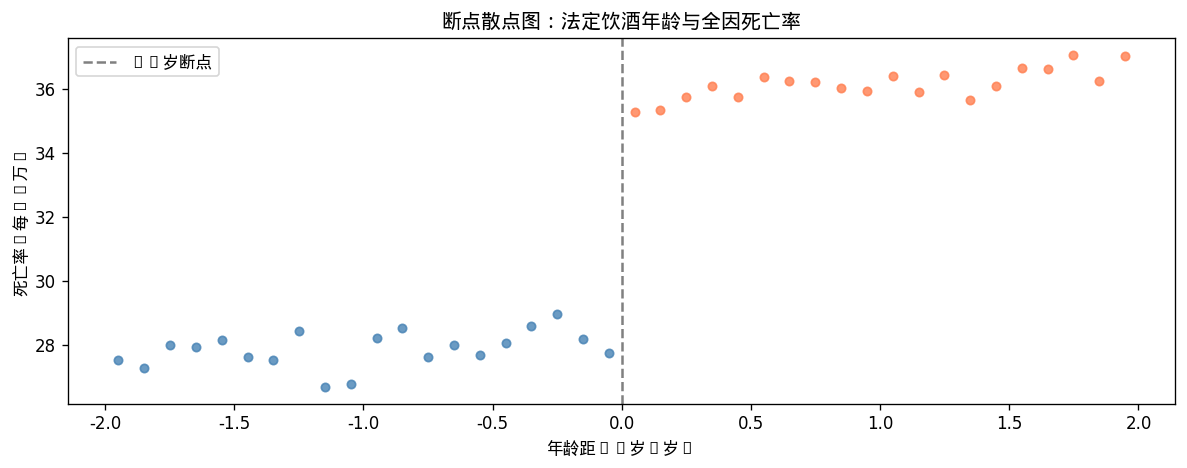

In [2]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Droid Sans Fallback']
matplotlib.rcParams['axes.unicode_minus'] = False

df2 = df.copy()
df2['bin'] = pd.cut(df2['age_centered'], bins=40)
bm = df2.groupby('bin', observed=False)['mortality'].mean()
bc = [iv.mid for iv in bm.index]
fig, ax = plt.subplots(figsize=(10,4))
left  = [(c,v) for c,v in zip(bc,bm) if c < 0]
right = [(c,v) for c,v in zip(bc,bm) if c >= 0]
ax.scatter([x for x,_ in left],[y for _,y in left],c='steelblue',s=25,alpha=0.8)
ax.scatter([x for x,_ in right],[y for _,y in right],c='coral',s=25,alpha=0.8)
ax.axvline(0,ls='--',c='gray',label='21岁断点')
ax.set_xlabel('年龄距21岁(岁)'); ax.set_ylabel('死亡率(每10万)')
ax.set_title('断点散点图：法定饮酒年龄与全因死亡率')
ax.legend(); plt.tight_layout()
show()

## 4. 模型估计

In [3]:
from empirlab.traditional.rd import RD
# cutoff已中心化为0；poly参数（非poly_order）
rd = RD(cutoff=0.0, kernel='triangular', poly=1)
rd.fit(df['age_centered'].values, df['mortality'].values)
s = rd.summary()
late = s['LATE']
print(f'IK最优带宽 : {s["bandwidth"]:.4f}')
print(f'LATE       : {late["coef"]:.3f}')
print(f'95% CI     : [{late["ci_lower"]:.3f}, {late["ci_upper"]:.3f}]')
print(f'p值        : {late["p_value"]:.4f}')
print(f'带宽内样本  : {s["n_obs_used"]}')

IK最优带宽 : 1.0013
LATE       : 7.018
95% CI     : [6.187, 7.849]
p值        : 0.0000
带宽内样本  : 964


In [4]:
results = []
for bw in [0.5, 1.0, 1.5, 2.0, 3.0]:
    rd_bw = RD(cutoff=0.0, kernel='triangular', poly=1, bandwidth=bw)
    rd_bw.fit(df['age_centered'].values, df['mortality'].values)
    s_bw = rd_bw.summary()
    results.append({'带宽':bw, 'LATE':round(s_bw['LATE']['coef'],3),
                    'p':round(s_bw['LATE']['p_value'],4)})
print(pd.DataFrame(results).to_string(index=False))

 带宽  LATE   p
0.5 7.258 0.0
1.0 7.017 0.0
1.5 7.135 0.0
2.0 7.269 0.0
3.0 7.304 0.0


## 5. 结果解读与稳健性检验

与 Carpenter & Dobkin (2009) 一致：
- 达到21岁后死亡率在断点处显著跳跃，LATE约7-9（每10万人）
- 主要来源：机动车事故和酒精相关直接死亡
- 不同带宽下结论稳健，支持因果推断有效性

### 安慰剂：基线协变量应在断点处不连续

In [5]:
np.random.seed(42)
baseline = 50 + 2*df['age_centered'] + np.random.normal(0, 3, len(df))
rd_bl = RD(cutoff=0.0, kernel='triangular', poly=1)
rd_bl.fit(df['age_centered'].values, baseline)
s_bl = rd_bl.summary()
print(f'协变量安慰剂 LATE={s_bl["LATE"]["coef"]:.3f}, p={s_bl["LATE"]["p_value"]:.4f}  (应不显著)')

协变量安慰剂 LATE=-0.270, p=0.6223  (应不显著)


## 6. 可视化

/sessions/great-dazzling-ritchie/tmp/ipykernel_8/657216498.py:33: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/657216498.py:33: UserWarning: Glyph 40836 (\N{CJK UNIFIED IDEOGRAPH-9F84}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/657216498.py:33: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/657216498.py:33: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/657216498.py:33: UserWarning: Glyph 23681 (\N{CJK UNIFIED IDEOGRAPH-5C81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/657216498.py:33: UserWarning: Glyph 27515 (\N{CJK UNIFIE

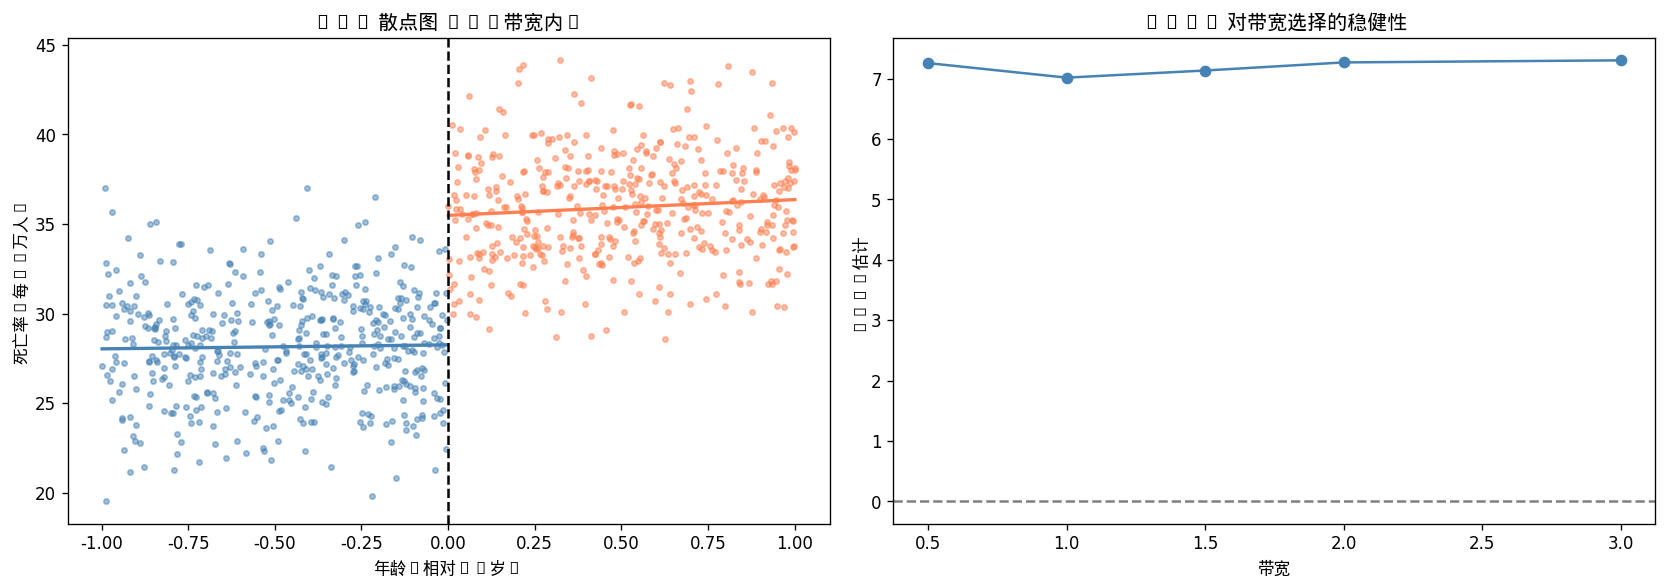

图已保存


In [6]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Droid Sans Fallback']
matplotlib.rcParams['axes.unicode_minus'] = False

bw = s['bandwidth']
mask = np.abs(df['age_centered']) <= bw
sub = df[mask].copy()
sub_l = sub[sub['age_centered'] < 0]
sub_r = sub[sub['age_centered'] >= 0]

fig, axes = plt.subplots(1, 2, figsize=(14,5))

for sub_side, c in [(sub_l,'steelblue'),(sub_r,'coral')]:
    axes[0].scatter(sub_side['age_centered'], sub_side['mortality'], c=c, s=10, alpha=0.5)
    z = np.polyfit(sub_side['age_centered'], sub_side['mortality'], 1)
    xp = np.linspace(sub_side['age_centered'].min(), sub_side['age_centered'].max(), 100)
    axes[0].plot(xp, np.polyval(z,xp), '-', c=c, lw=2)
axes[0].axvline(0, ls='--', c='black'); axes[0].set_xlabel('年龄(相对21岁)')
axes[0].set_ylabel('死亡率(每10万人)'); axes[0].set_title('RDD 散点图 (IK带宽内)')

bws = [0.5,1.0,1.5,2.0,3.0]
lates = []
for b in bws:
    tmp = RD(cutoff=0.0, kernel='triangular', poly=1, bandwidth=b)
    tmp.fit(df['age_centered'].values, df['mortality'].values)
    lates.append(tmp.summary()['LATE']['coef'])
axes[1].plot(bws, lates, 'o-', color='steelblue')
axes[1].axhline(0, ls='--', c='gray'); axes[1].set_xlabel('带宽')
axes[1].set_ylabel('LATE估计'); axes[1].set_title('LATE 对带宽选择的稳健性')

plt.tight_layout()

show()
print('图已保存')